# Primitive fitting

This notebook introduces techniques for fitting geometric primitives to pointclouds. **Instead of representing geometry using a large collection of sampled points, primitive fitting approximates it with a parametric shape described by a small number of parameters.**. This process is often called *abstraction* as low-level point samples are replaced by higher-level geometric entities.

Common primitives include **planes, spheres, cylinders, cones, and tori**. The goal is to find the parameters of the primitive that best fits a set of points. The following sections present the parameterization, distance measures, and fitting algorithms used for each primitive.

## About fitting

Primitive fitting is an optimization problem. Given a set of points and a primitive of known type, the goal is to find the parameters $\theta$ that best fit the points.

This is typically done by minimizing the sum of squared distances between the points and the primitive:

\begin{equation*}
res(\theta) = \sum_{i=0}^{n-1} d(p_{i}, S(\theta))^{2}
\end{equation*}

This quantity is called the **residual**.

The above formulation assumes that all points are affected by the same level of measurement noise. If this is not the case, each point can be assigned a weight according to its expected uncertainty.

For simplicity, the remainder of this notebook uses the notation:

\begin{equation*}
E(\theta) = \sum_{i=0}^{n-1} f_{i} (\theta)^{2}
\end{equation*}

where $E$ is the error function and $f_{i}$ is the residual associated with point $p_{i}$.

The choice of distance function strongly influences the optimization process. In general, it is preferable to keep the number of parameters as small as possible. For example, a unit normal vector can be represented using spherical coordinates instead of Cartesian coordinates. Since $\lVert n \rVert = 1$, only two parameters are needed instead of three.


In [71]:
# Necessary imports
import sys
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize, least_squares

sys.path.append("./utils")
from manip_utils import (rotation_f_to_t, cartesian_to_spherical, 
                         spherical_to_cartesian)
from plot_utils import (generate_plane_mesh, generate_sphere_mesh, 
                        generate_cylinder_mesh, generate_cone_mesh, 
                        generate_torus_mesh)

## Plane

### Plane parameters

A plane can be represented in several ways. The most common is its Cartesian equation:

\begin{equation*}
    a x + b y + c z + d = 0
\end{equation*}

where $[a, b, c]$ defines the plane normal direction and $d$ is the plane offset. An equivalent representation uses a normal vector $n = [a, b, c]$ and a point $p$ lying on the plane and satisfying $p \cdot n = -d$. Both representations describe an infinite plane.

A bounded planar surface can be represented by a rectangular plane defined by the parameters below. The width direction is implicitly given by $b = n \times t$, where $n$ and $t$ are orthogonal unit vectors.

| Parameter | Description |
|:----------|:------------|
| $c$       | center of the plane |
| $n$       | unit normal vector |
| $t$       | unit vector defining the length direction |
| $l$       | length |
| $w$       | width |

In [72]:
def generate_plane_points(center, normal, tangent, length, width, n=1000):
    """Generate random points on a rectangular plane."""

    # Generate points on a unit plane
    x = np.random.uniform(-.5, .5, n)
    y = np.random.uniform(-.5, .5, n)
    z = np.zeros(n)
    points = np.stack((x, y, z), axis=1)
    # Scale to the desired dimensions
    points[:, 0] *= length
    points[:, 1] *= width
    # Rotate to the desired orientation
    R = np.stack((tangent, np.cross(normal, tangent), normal), axis=1)
    points = (R @ points.T).T
    # Translate to the desired position
    return points + center


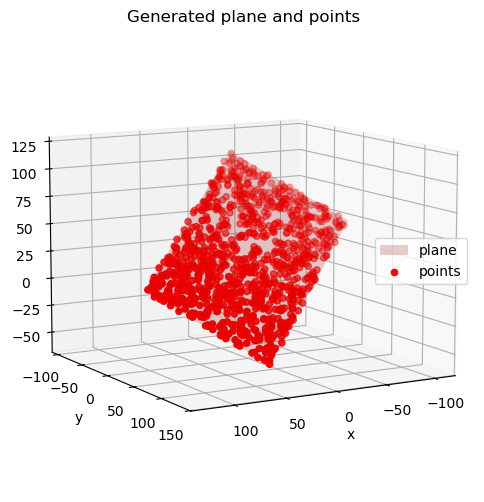

In [73]:
# Define plane parameters
plane_parameters = (
    np.array([10., 20., 30.]), # center
    np.array([0., np.sqrt(2)/2., np.sqrt(2)/2.]), # normal
    np.array([np.sqrt(2)/2., 0.5, -0.5]), # tangent
    200., # length
    125. # width
)
# Generate points
points_plane = generate_plane_points(*plane_parameters)
# Generate a mesh for visualization
plane_vertices, plane_faces = generate_plane_mesh(*plane_parameters)

# Plot the plane and points
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot_trisurf(plane_vertices[:, 0], plane_vertices[:,1], plane_vertices[:,2], 
                triangles=plane_faces, color="red", alpha=0.2, label="plane")
ax.scatter(points_plane[:, 0], points_plane[:, 1], points_plane[:, 2],
           c="red", label="points")
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.legend(loc="right")
ax.view_init(10, 60)
ax.axis("equal")
ax.set_title("Generated plane and points")
plt.show()

### Point-to-plane distance

The distance between a point $p$ and a rectangular plane $P$ is given by:

\begin{equation*}
d(p, P) = \sqrt{d_{n}^2 + \max(0, |d_{l}| - l/2)^2 + \max(0, |d_{w}| - w/2)^2}
\end{equation*}

where

\begin{equation*}
    d_{n} = n \cdot (p - c) 
    \quad 
    d_{l} = t \cdot (p - c)
    \quad
    d_{w} = (n \times t) \cdot (p - c)
\end{equation*}

For an infinite plane, the last two terms vanish and the distance reduces to $ | d_{n} | $.

The above distance is unsigned. In some situations, it is useful to distinguish the side of the plane on which the point lies. A signed distance can then be defined as:

\begin{equation*}
d(p, P) = \text{sign}(d_{n}) . \sqrt{d_{n}^2 + \max(0, |d_{l}| - l/2)^2 + \max(0, |d_{w}| - w/2)^2}
\end{equation*}

Positive distances correspond to the side pointed to by the normal vector $ n $.

In [74]:
def dist_to_plane(points, center, normal, tangent=None, length=None, width=None):
    """Signed distance to the plane."""

    # Distance along the normal direction
    vec_to_center = points - center
    d_n = vec_to_center @ normal
    if tangent is None:
        return d_n
    # Distance in the plane directions
    d_l = vec_to_center @ tangent
    d_w = vec_to_center @ np.cross(normal, tangent)
    # Distance outside finite bounds
    d_l_out = 0. if length is None else np.maximum(0., np.abs(d_l) - length/2)
    d_w_out = 0. if width is None else np.maximum(0., np.abs(d_w)- width/2)
    # Distance to a finite plane
    d_total = np.sqrt(d_n**2 + d_l_out**2 + d_w_out**2)
    # Signed distance
    sign = np.where(d_n < 0, -1., 1.)
    return sign * d_total


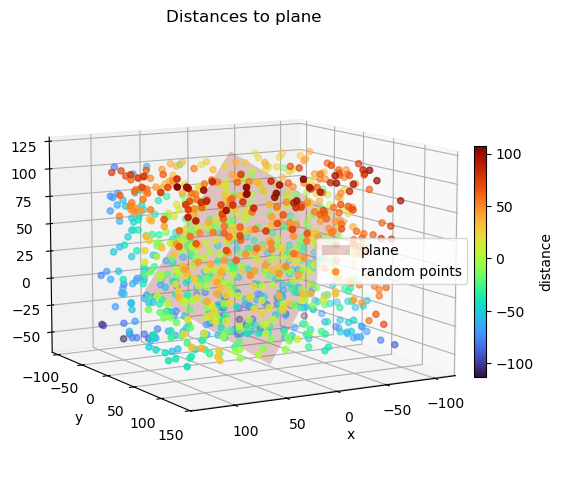

In [75]:
# Generate random points and compute distances to the plane
random_points = np.random.uniform(
    points_plane.min(axis=0), points_plane.max(axis=0), (1000, 3)
)
dists_plane = dist_to_plane(random_points, *plane_parameters)

# Plot distances to the plane
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot_trisurf(plane_vertices[:,0], plane_vertices[:,1], plane_vertices[:,2], 
                triangles=plane_faces, color="red", alpha=0.2, label="plane")
p = ax.scatter(random_points[:, 0], random_points[:, 1], random_points[:, 2],
               c=dists_plane, cmap="turbo", label="random points")
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.legend(loc="right")
ax.view_init(10, 60)
cbar = fig.colorbar(p, shrink=0.5, pad=0)
cbar.set_label('distance')
ax.axis("equal")
ax.set_title("Distances to plane")
plt.show()

### Least squares plane

The least-squares plane can be estimated either using a nonlinear optimizer or through a closed-form solution based on *Principal Component Analysis* (PCA). Since the PCA approach is simpler, faster, and does not require initialization, it is generally preferred.

First, the covariance matrix of the pointcloud is computed:

\begin{equation*}
    cov = \sum_{i=0}^{n-1} (p_{i} - \bar{p}) \cdot (p_{i} - \bar{p})^{T}
    \qquad 
    \bar{p} = \frac{1}{n} \sum^{n-1}_{i=0} p_{i}
\end{equation*}

Its decomposition gives the eigenvalues $\lambda_1 \geq \lambda_2 \geq \lambda_3$ and corresponding eigenvectors $\nu_1$, $\nu_2$ and $\nu_3$.

The smallest eigenvalue $\lambda_3$ is equal to the residual, and the optimal plane directions are:

\begin{equation*}
    n = \nu_{3}
    \qquad
    t = \nu_{1}
\end{equation*}

Note that the signs of the eigenvectors are arbitrary.

For an infinite plane, the center is simply the centroid $\bar{p}$.

For a bounded rectangular plane, the center, length, and width are obtained by projecting the points onto the principal axes. Note that the area of the resulting rectangle is not minimal.

In [76]:
def fit_plane(points):
    """Best-fit plane to a pointcloud."""

    # Center pointcloud
    centroid = points.mean(axis=0)
    centered_points = points - centroid
    # Covariance matrix
    cov = centered_points.T @ centered_points
    # Eigenvalues are returned in ascending order
    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    # Smallest eigenvalue = residual
    residual = eigenvalues[0]
    # Plane directions
    normal = eigenvectors[:, 0]
    tangent = eigenvectors[:, 2]
    # Project points onto the principal axes
    projected_points = (eigenvectors.T @ centered_points.T).T
    # Bounding rectangle dimensions
    _, width, length = np.ptp(projected_points, axis=0)
    bbox_center = (projected_points.max(axis=0)+projected_points.min(axis=0))/2
    # Center of the bounding rectangle
    shift = np.array([0., bbox_center[1], bbox_center[2]])
    center = centroid + eigenvectors @ shift

    return (center, normal, tangent, length, width), residual


best-fit plane center is: [10.52  20.265 29.735]
best-fit plane normal is: [0.    0.707 0.707]
best-fit plane tangent is: [-0.724 -0.488  0.488]
best-fit plane length is: 201.07486524938815
best-fit plane width is: 128.7465900297416
residual is: 1.1464843474163646e-12


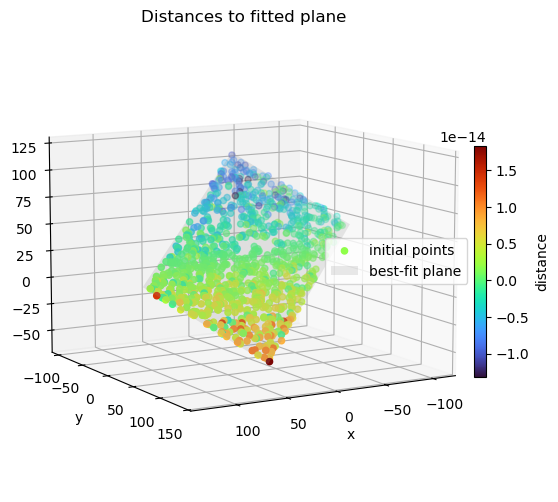

In [77]:
# Fit plane to pointcloud
plane_fit, plane_residual = fit_plane(points_plane)
# Display estimated parameters
with np.printoptions(precision=3, suppress=True):
    for name, val in zip(
        ["center", "normal", "tangent", "length", "width"],
        plane_fit
    ):
        print(f"best-fit plane {name} is: {val}")
    print(f"residual is: {plane_residual}")
# Generate mesh for visualization purposes
plane_fit_vertices, plane_fit_faces = generate_plane_mesh(*plane_fit)
# Show distance to best-fit plane
dists_plane_fit = dist_to_plane(points_plane, *plane_fit)

# Plot best-fit plane and distances
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
p = ax.scatter(points_plane[:, 0], points_plane[:, 1], points_plane[:, 2],
          c=dists_plane_fit, cmap="turbo", label="initial points")
ax.plot_trisurf(plane_fit_vertices[:, 0], plane_fit_vertices[:, 1],
                plane_fit_vertices[:, 2], triangles=plane_fit_faces, 
                color="white", alpha=0.2, label="best-fit plane")
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.legend(loc="right")
ax.view_init(10, 60)
cbar = fig.colorbar(p, shrink=0.5, pad=0)
cbar.set_label("distance")
ax.axis("equal")
ax.set_title("Distances to fitted plane")
plt.show()


## Sphere

### Sphere parameters

A full sphere is defined by its center $c$ and radius $r$. Its Cartesian equation is:

\begin{equation*}
    (x - c_{x})^{2} + (y - c_{y})^{2} + (z - c_{z})^{2} = r^{2}
\end{equation*}

| Parameter | Description |
|:----------|:------------|
| $c$       | center |
| $r$       | radius |


In [78]:
def generate_sphere_points(center, radius, n=1000):
    """Random points on a sphere."""

    # Generate points on a unit sphere
    phi = np.random.uniform(0., 2*np.pi, (n, 1))
    z = np.random.uniform(-1., 1., (n, 1))
    rho = np.sqrt(1 - z**2)
    x = rho * np.cos(phi)
    y = rho * np.sin(phi)
    points = np.hstack((x, y, z))
    # Scale to the desired radius
    points *= radius
    # Translate to the desired position
    return points + center

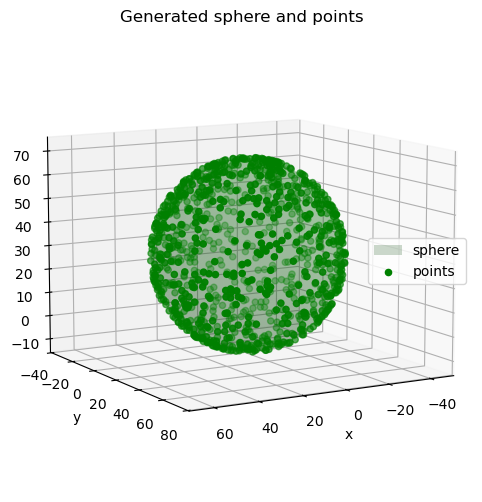

In [79]:
# Define sphere parameters
sphere_parameters = (
    np.array([10., 20., 30.]), # center
    40. # radius
)
# Generate points
points_sphere = generate_sphere_points(*sphere_parameters)
# Generate a mesh for visualization
sphere_vertices, sphere_faces = generate_sphere_mesh(*sphere_parameters)

# Plot points and sphere
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot_trisurf(sphere_vertices[:, 0], sphere_vertices[:, 1],
                sphere_vertices[:, 2], triangles=sphere_faces, color="green", 
                alpha=.2, label="sphere")
ax.scatter(points_sphere[:, 0], points_sphere[:, 1], points_sphere[:, 2],
           c="green", label="points")
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.legend(loc="right")
ax.view_init(10, 60)
ax.axis("equal")
ax.set_title("Generated sphere and points")
plt.show()

### Point-to-sphere distance

The signed distance between a point $p$ and a sphere $S$ is simply given by:

\begin{equation*}
    d(p, S) = || p - c || - r
\end{equation*}

Positive distances correspond to points outside the sphere, while negative distances correspond to points inside it.

In [80]:
def dist_to_sphere(points, center, radius):
    """Signed distance to a sphere."""

    return np.linalg.norm(points - center, axis=1) - radius


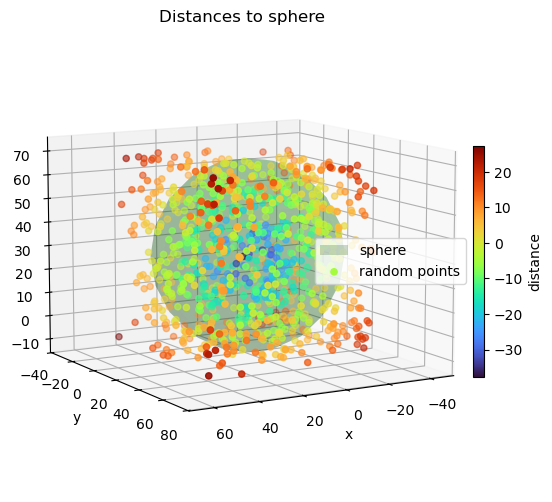

In [81]:
# Generate random points and compute their distance to the sphere
random_points = np.random.uniform(
    points_sphere.min(axis=0), points_sphere.max(axis=0), (1000, 3)
)
dists_sphere = dist_to_sphere(random_points, *sphere_parameters)

# Plot distances
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot_trisurf(sphere_vertices[:, 0], sphere_vertices[:, 1],
                sphere_vertices[:, 2], triangles=sphere_faces, color="green", 
                alpha=0.2, label="sphere")
p = ax.scatter(random_points[:, 0], random_points[:, 1], random_points[:, 2],
               c=dists_sphere, cmap="turbo", label="random points")
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.legend(loc="right")
ax.view_init(10, 60)
cbar = fig.colorbar(p, shrink=0.5, pad=0)
cbar.set_label('distance')
ax.axis("equal")
ax.set_title("Distances to sphere")
plt.show()

### Least squares sphere

A least-squares sphere can be estimated either using a nonlinear optimizer or through a direct linear least-squares formulation. The latter is simpler and does not require initialization.

Starting from the Cartesian equation of the sphere:

\begin{equation*}
(x - c_{x})^{2} + (y - c_{y})^{2} + (z - c_{z})^{2} = r^{2}
\end{equation*}

expanding and regrouping terms gives:

\begin{equation*}
    2 x c_{x} + 2 y c_{y} + 2 z c_{z} + r^{2} - c_{x}^{2} - c_{y}^{2} - c_{z}^{2} = x^{2} + y^{2} + z^{2}
\end{equation*}

Introducing:

\begin{equation*}
    t = r^{2} - c_{x}^{2} - c_{y}^{2} - c_{z}^{2}
\end{equation*}

gives the linear system:

\begin{equation*}
 2 x c_{x} + 2 y c_{y} + 2 z c_{z} + t = x^{2} + y^{2} + z^{2}
\end{equation*}

The fitting problem can therefore be written as a linear least-squares problem $Ax = b$ with unknowns $x = [c_{x}, c_{y}, c_{z}, t]$. Once solved, the sphere center is obtained directly from $(c_{x}, c_{y}, c_{z})$, and the radius is recovered from $t$.

In [82]:
def fit_sphere(points):
    """Best-fit sphere to a pointcloud."""

    # Linear least-squares system
    A = np.column_stack((2*points, np.ones(len(points))))
    b = (points**2).sum(axis=1)
    # Solve A x = b
    x, residual, _, _ = np.linalg.lstsq(A, b, rcond=None)
    # Recover sphere parameters
    center = x[:3]
    radius = np.sqrt(x[0]**2 + x[1]**2 + x[2]**2 + x[3])
   
    return (center, radius), residual


best-fit sphere center is: [10. 20. 30.]
best-fit sphere radius is: 39.99999999999999
residual is: [0.]


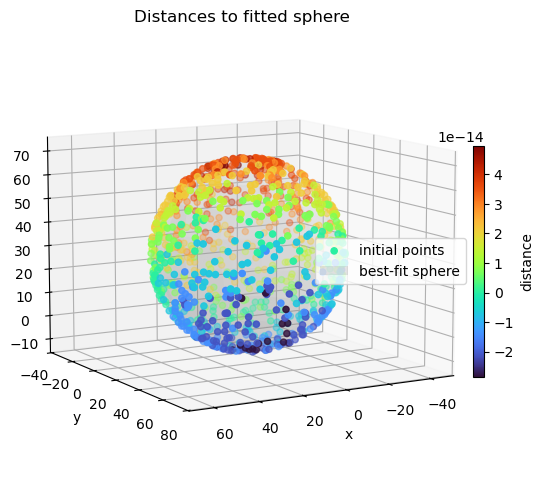

In [83]:
# Fit sphere to pointcloud
sphere_fit, sphere_residual = fit_sphere(points_sphere)
# Display estimated parameters
with np.printoptions(precision=3, suppress=True):
    for name, val in zip(["center", "radius"], sphere_fit):
        print(f"best-fit sphere {name} is: {val}")
    print(f"residual is: {sphere_residual}")
# Generate a mesh for visualization
sphere_fit_vertices, sphere_fit_faces = generate_sphere_mesh(*sphere_fit)
# Show distance to fitted sphere
dists_sphere_fit = dist_to_sphere(points_sphere, *sphere_fit)

# Plot distances
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
p = ax.scatter(points_sphere[:, 0], points_sphere[:, 1], points_sphere[:, 2],
               c=dists_sphere_fit, cmap="turbo", label="initial points")
ax.plot_trisurf(sphere_fit_vertices[:, 0], sphere_fit_vertices[:, 1],
                sphere_fit_vertices[:, 2], triangles=sphere_fit_faces,
                color="white", alpha=0.2, label="best-fit sphere")
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.legend(loc="right")
ax.view_init(10, 60)
cbar = fig.colorbar(p, shrink=0.5, pad=0)
cbar.set_label('distance')
ax.axis("equal")
ax.set_title("Distances to fitted sphere")
plt.show()

## Cylinder

### Cylinder parameters

An infinite cylinder aligned with the $z$-axis can be represented by the Cartesian equation:

\begin{equation*}
    (x - c_{x})^{2} + (y - c_{y})^{2} = r^{2}
\end{equation*}

A finite cylinder of arbitrary orientation is considered here. It is defined by its center $c$, axis direction $n$, radius $r$ and length $l$. The cylinder is bounded by two planes perpendicular to $n$ and separated by a distance $l$. The center $c$ lies halfway between these planes.

| Parameter | Description |
|:----------|:------------|
| $c$       | center |
| $n$       | unit vector defining the axis direction |
| $r$       | radius |
| $l$       | length |


In [84]:
def generate_cylinder_points(center, normal, radius, length, n=1000):
    """Generate random points on a cylinder."""

    # Generate points on a unit cylinder
    theta = np.random.uniform(0., 2*np.pi, (n, 1))
    x = np.cos(theta)
    y = np.sin(theta)
    z = np.random.uniform(-0.5, 0.5, (n, 1))
    points = np.hstack((x, y, z))
    # Scale to the desired dimensions
    points[:, :2] *= radius
    points[:, 2] *= length
    # Rotate to the desired orientation
    R = rotation_f_to_t(np.array([0., 0., 1.]), normal)
    points = (R @ points.T).T
    # Translate to the desired position
    return points + center


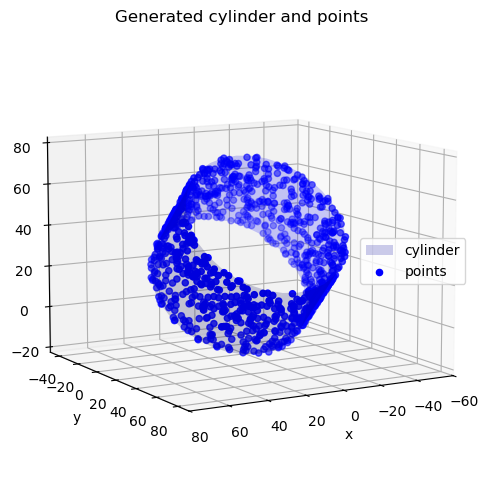

In [85]:
# Define cylinder parameters
cylinder_parameters = (
    np.array([10., 20., 30.]), # center
    np.array([0., np.sqrt(2)/2., np.sqrt(2)/2.]), # axis direction
    40., # radius
    50. # length
)
# Generate mesh for visualization
cylinder_vertices, cylinder_faces = generate_cylinder_mesh(*cylinder_parameters)
# Generate points
points_cylinder = generate_cylinder_points(*cylinder_parameters)

# Plot the cylinder and points
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot_trisurf(cylinder_vertices[:, 0], cylinder_vertices[:, 1],
                cylinder_vertices[:, 2], triangles=cylinder_faces,
                color="blue", alpha=0.2, label="cylinder")
ax.scatter(points_cylinder[:, 0], points_cylinder[:, 1], points_cylinder[:, 2],
           c="blue", label="points")
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.legend(loc="right")
ax.view_init(10, 60)
ax.axis("equal")
ax.set_title("Generated cylinder and points")
plt.show()

### Points-to-cylinder distance

For an infinite cylinder, the signed distance between a point $p$ and a cylinder $C$ is:

\begin{equation*}
    d_{r}(p, C) = || n \times (p - c) || - r
\end{equation*}

where the first term is the distance between the point and the cylinder axis. Positive distances correspond to points outside the cylinder, while negative distances correspond to points inside it.

For a finite cylinder, the position of the point along the axis must also be considered:

\begin{equation*}
    d_{a}(p, C) = n \cdot (p - c)
\end{equation*}

Points satisfying:

\begin{equation*}
    | d_{a}(p, C) | > l/2
\end{equation*}

lie beyond one of the cylinder bounds. Their distance is then computed with respect to the corresponding bounding circle:

\begin{equation*}
    d(p, C_i) = \sqrt{[n \cdot (p - c_i)]^2 + (|| n \times (p - c_i) || - r)^2}
\end{equation*}

where

\begin{equation*}
    c_{1} = c - \frac{l}{2}n
    \qquad
    c_{2} = c + \frac{l}{2}n.
\end{equation*}

For all other points, the cylinder distance is simply

\begin{equation*}
    d(p, C) = d_{r}(p, C)
\end{equation*}


In [86]:
def dist_to_cylinder(points, center, normal, radius, length=None):
    """Signed distance to the cylinder."""

    # Distance to the cylinder axis
    vec_to_center = points - center
    dist_to_axis = np.linalg.norm(np.cross(normal, vec_to_center), axis=1)
    # Infinite cylinder
    d_r = dist_to_axis - radius
    if length is None:
        return d_r
    d_t = np.zeros(len(d_r), dtype=float) # total distance
    # Position along the axis
    d_a = vec_to_center @ normal
    # Points between the two bounds
    inds_in = np.nonzero(np.abs(d_a) <= length / 2)[0]
    d_t[inds_in] = d_r[inds_in]
    # Points beyond the first bound
    inds_out_1 = np.nonzero(d_a < -length / 2)[0]
    c_1 = center - length / 2 * normal
    vec_to_c_1 = points[inds_out_1] - c_1
    dist_to_axis_1 = np.linalg.norm(np.cross(normal, vec_to_c_1), axis=1)
    d_t[inds_out_1] = np.sqrt(
        (vec_to_c_1 @ normal)**2 + (dist_to_axis_1 - radius)**2
    )
    # Points beyond the second bound
    inds_out_2 = np.nonzero(d_a > length / 2)[0]
    c_2 = center + length / 2 * normal
    vec_to_c_2 = points[inds_out_2] - c_2
    dist_to_axis_2 = np.linalg.norm(np.cross(normal, vec_to_c_2), axis=1)
    d_t[inds_out_2] = np.sqrt(
        (vec_to_c_2 @ normal)**2 + (dist_to_axis_2 - radius)**2
    )
    
    return d_t


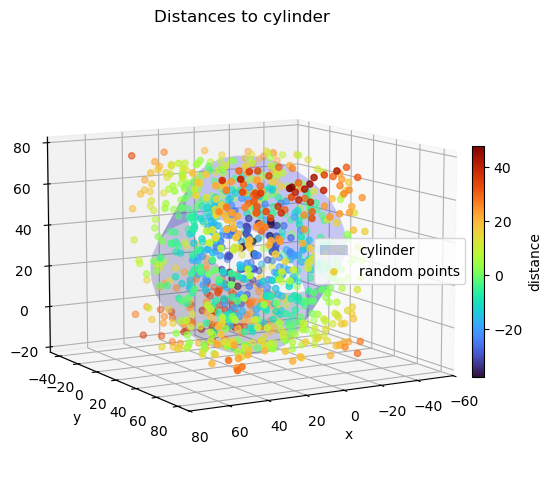

In [87]:
# Generate random points and compute distance to the cylinder
random_points = np.random.uniform(
    points_cylinder.min(axis=0), points_cylinder.max(axis=0), (1000, 3)
)
dists_cylinder = dist_to_cylinder(random_points, *cylinder_parameters)

# Plot the distances
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot_trisurf(cylinder_vertices[:, 0], cylinder_vertices[:, 1],
                cylinder_vertices[:, 2], triangles=cylinder_faces,
                color="blue", alpha=0.2, label="cylinder")
p = ax.scatter(random_points[:, 0], random_points[:, 1], random_points[:, 2],
               c=dists_cylinder, cmap="turbo", label="random points")
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.legend(loc="right")
ax.view_init(10, 60)
cbar = fig.colorbar(p, shrink=0.5, pad=0)
cbar.set_label("distance")
ax.axis("equal")
ax.set_title("Distances to cylinder")
plt.show()


### Least-squares cylinder

Unlike planes and spheres, cylinders do not admit a simple closed-form least-squares solution. The approach presented here follows \cite{eberly1999least}.

Using the Cartesian equation of the cylinder, a point $p$ belongs to the cylinder if its squared distance to the axis of unit direction $n$ is equal to the squared radius:

\begin{equation*}
    r^{2} = (p - c)^T (I - nn^T)(p - c)
\end{equation*}

This leads to the implicit cylinder function:

\begin{equation*}
    f(c, n, r^2) = (p - c)^T (I - nn^T)(p - c) - r^{2}
\end{equation*}

and the associated least-squares problem:

\begin{equation*}
E(c, n, r^{2}) = \sum_{i=0}^{N-1} f_{i} (c, n, r^{2})^{2}
\end{equation*}

The unknowns are the cylinder center $c$, axis direction $n$ and squared radius $r^2$.

The parameters may be estimated using a nonlinear least-squares optimizer such as Levenberg-Marquardt. However, convergence strongly depends on the quality of the initial guess.

An alternative approach, proposed by Eberly, minimizes an auxiliary function $G$ derived from the stationary points of the problem. Although still iterative, this method avoids directly minimizing $E$ and generally provides more robust estimates.

The implementation below follows this second approach. It first estimates the cylinder axis by minimizing the function $G$, then recovers the center, radius, and length analytically. Most computations are vectorized. The minimization is performed with Powell's method, which provides good results in practice and avoids the need to compute derivatives of $G$.

In [88]:
def fit_cylinder(points, normal_guess=[0., 0., 1.]):
    """Best-fit cylinder to a pointcloud."""

    # Initial direction estimate
    start_point = cartesian_to_spherical(normal_guess)
    # Center the pointcloud
    centroid = points.mean(axis=0)
    centered_points = points - centroid
    # Estimate the cylinder axis
    best_fit = minimize(
        lambda x : G(spherical_to_cartesian(x), centered_points),
        start_point,
        method="Powell",
    )
    normal = spherical_to_cartesian(best_fit.x)
    residual = best_fit.fun
    # Recover the remaining parameters
    # Projection matrix P
    P = np.eye(3) - normal.reshape(-1, 1) @ normal.reshape(1, -1)
    # Projected points
    projected_points = (P @ centered_points.T).T
    # Inertia matrix
    A = projected_points.T @ projected_points
    # Skew symmetric matrix
    S = np.array([
        [0, -normal[2], normal[1]],
        [normal[2], 0, -normal[0]],
        [-normal[1], normal[0], 0]
    ])
    # Adjugate matrix
    A_hat = S @ (A @ S.T)
    # Center
    center = (
        A_hat/np.trace(A_hat @ A)
    ) @ (
        (projected_points * projected_points).sum(axis=1).reshape(-1, 1) 
        * projected_points
    ).sum(axis=0)
    center += centroid
    # Radius
    r2 = np.mean(np.sum(((points - center) @ P) * (points - center), axis=1))
    radius = np.sqrt(r2)    
    # Length
    length = np.ptp((points - center) @ normal)
    
    return (center, normal, radius, length), residual # residual of G function!


def G(normal, centered_points):
    """Cylinder objective function."""
    
    # Projection matrix
    P = np.eye(3) - normal.reshape(3, 1) @ normal.reshape(1, 3)
    # Projected points
    projected_points = (P @ centered_points.T).T
    # Inertia matrix
    A = projected_points.T @ projected_points
    # Skew symmetric matrix
    S = np.array([
        [0, -normal[2], normal[1]],
        [normal[2], 0, -normal[0]],
        [-normal[1], normal[0], 0]
    ])
    # Adjugate matrix
    A_hat = S @ (A @ S.T)
    # Intermediate terms for the G function
    s = (projected_points**2).sum(axis=1).reshape(-1, 1)
    u = s.sum()/len(centered_points)
    v = (A_hat / np.trace(A_hat @ A)) @ (s * projected_points).sum(axis=0)
    
    return ((s - u - 2*(projected_points @ v).reshape(-1, 1))**2).sum()


best-fit cylinder center is: [10.    19.864 29.864]
best-fit cylinder normal is: [0.    0.707 0.707]
best-fit cylinder radius is: 40.0
best-fit cylinder length is: 49.911994088158025
residual of G is: 1.0642980307792687e-22


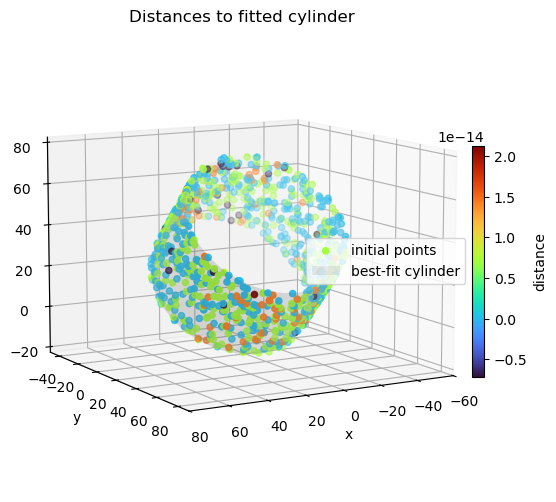

In [89]:
# Fit the cylinder
cylinder_fit, cylinder_residual = fit_cylinder(points_cylinder)
# Display estimated parameters
with np.printoptions(precision=3, suppress=True):
    for name, val in zip(
        ["center", "normal", "radius", "length"],
        cylinder_fit
    ):
        print(f"best-fit cylinder {name} is: {val}")
    print(f"residual of G is: {cylinder_residual}")
    
# Generate a mesh for visualization
cylinder_fit_vertices,cylinder_fit_faces= generate_cylinder_mesh(*cylinder_fit)
# Compute distances to the fitted infinite cylinder to avoid numerical errors
dists_cylinder_fit = dist_to_cylinder(points_cylinder, *cylinder_fit[:-1])

# Plot the fitted cylinder and distances
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
p = ax.scatter(points_cylinder[:, 0], points_cylinder[:, 1], 
               points_cylinder[:, 2], c=dists_cylinder_fit, cmap="turbo", 
               label="initial points")
ax.plot_trisurf(cylinder_fit_vertices[:, 0], cylinder_fit_vertices[:, 1],
                cylinder_fit_vertices[:, 2], triangles=cylinder_fit_faces,
                color="white", alpha=0.2, label="best-fit cylinder")
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.legend(loc="right")
ax.view_init(10, 60)
cbar = fig.colorbar(p, shrink=0.5, pad=0)
cbar.set_label("distance")
ax.axis("equal")
ax.set_title("Distances to fitted cylinder")
plt.show()

## Cone

### Cone parameters

An infinite cone aligned with the $z$-axis can be represented by:

\begin{equation*}
    (x - c_{x})^2 + (y - c_{y})^2 = (z - c_{z})^2.\tan^{2} \alpha
\end{equation*}

This equation defines a double cone of half-angle $\alpha$, with two symmetric branches meeting at the apex $c$.

Only one branch is considered here, resulting in a semi-infinite cone bounded by its apex and extending in the direction $-n$. A finite cone is obtained by truncating this semi-infinite cone with a plane perpendicular to the axis at a distance $l$ from the apex. It is therefore defined by its apex $c$, axis direction $n$, half-angle $\alpha$, and length $l$.

| Parameter | Description |
|:----------|:------------|
| $c$       | apex position |
| $n$       | unit vector defining the axis direction |
| $\alpha$  | half-angle |
| $l$       | length |


In [90]:
def generate_cone_points(apex, normal, half_angle, length, n=1000):
    """Generate random points on a cone."""

    # Generate points on a cone aligned with the z-axis
    z = np.random.uniform(-length, 0., (n, 1))
    theta = np.random.uniform(0., 2*np.pi, (n, 1))
    x = z * np.tan(half_angle) * np.cos(theta)
    y = z * np.tan(half_angle) * np.sin(theta)
    points = np.hstack((x, y, z))
    # Rotate to the desired orientation
    R = rotation_f_to_t(np.array([0., 0., 1.]), normal)
    points = (R @ points.T).T
    # Translate to the desired position
    return points + apex


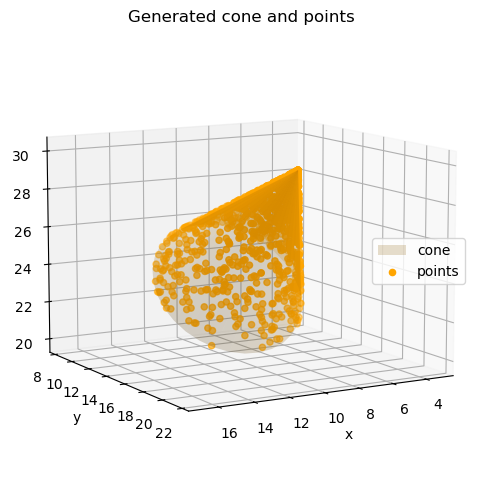

In [91]:
# Define cone parameters
cone_parameters = (
    np.array([10., 20., 30.]), # apex
    np.array([0., np.sqrt(2)/2., np.sqrt(2)/2.]), # axis direction
    np.pi/8, # half-angle
    10. # length
)
# Generate points
points_cone = generate_cone_points(*cone_parameters)
# Generate a mesh for visualization
cone_vertices, cone_faces = generate_cone_mesh(*cone_parameters)

# Plot the cone and points
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot_trisurf(cone_vertices[:, 0], cone_vertices[:, 1], cone_vertices[:, 2], 
                triangles=cone_faces, color="orange", alpha=0.2, label="cone")
ax.scatter(points_cone[:, 0], points_cone[:, 1], points_cone[:, 2],
           c="orange", label="points")
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.legend(loc="right")
ax.view_init(10, 60)
ax.axis("equal")
ax.set_title("Generated cone and points")
plt.show()


### Point-to-cone distance

For an infinite cone, the signed distance between a point $p$ and a cone $C$ is:

\begin{equation*}
    d_r(p, C) = (|| n \times (p - c) || - |(p - c) \cdot n| \tan\alpha) \cos \alpha
\end{equation*}

The first term is the distance between the point and the cone axis, while the second is the radius of the cone at the same position along the axis. Positive distances correspond to points outside the cone, while negative distances correspond to points inside it.

For a finite cone, the position of the point along the axis must also be considered:

\begin{equation*}
    d_a(p, C) = n \cdot (p - c)
\end{equation*}

Points satisfying:

\begin{equation*}
    d_a(p, C) > 0
\end{equation*}

lie beyond the apex. Their distance is simply:

\begin{equation*}
    d(p, c) = || p - c ||
\end{equation*}

Points satisfying:

\begin{equation*}
    d_a(p, C) < - l
\end{equation*}

lie beyond the cone base. Their distance is computed with respect to the bounding circle:

\begin{equation*}
    d(p, C_{1}) = \sqrt{[n \cdot (p - c_{1})]^2 + (\|n \times (p - c_{1})\| - r)^2 }
\end{equation*}

where

\begin{equation*}
    c_{1} = c - l n
    \qquad
    r = l \tan\alpha
\end{equation*}

For all other points, the cone distance is simply:

\begin{equation*}
    d(p, C) = d_r(p, C)
\end{equation*}


In [92]:
def dist_to_cone(points, apex, normal, half_angle, length=None):
    """Signed distance to the cone."""

    # Distance to axis
    vec_to_apex = points - apex
    dist_to_axis = np.linalg.norm(np.cross(normal, vec_to_apex), axis=1)
    # Position along the axis
    d_a = vec_to_apex @ normal
    # Cone radius along the axis
    r_a = np.abs(d_a) * np.tan(half_angle)
    # Total distance
    d_t = np.zeros(len(points), dtype=float)
    # Points between the apex and the base
    mask_in = d_a < 0
    d_r = (dist_to_axis - r_a) * np.cos(half_angle)
    d_t[mask_in] = d_r[mask_in]
    # Points beyond the apex
    mask_apex = d_a >= 0
    d_t[mask_apex] = np.linalg.norm(points[mask_apex] - apex, axis=1)
    # Points beyond the base
    if length is not None:
        mask_base = d_a <= -length
        r_base = length * np.tan(half_angle)
        c_base = apex - length * normal
        vec_to_base = points[mask_base] - c_base
        dist_to_axis_base = np.linalg.norm(
            np.cross(normal, vec_to_base),
            axis=1
        )
        d_t[mask_base] = np.sqrt(
            (vec_to_base @ normal)**2 + (dist_to_axis_base - r_base)**2
        )
    return d_t


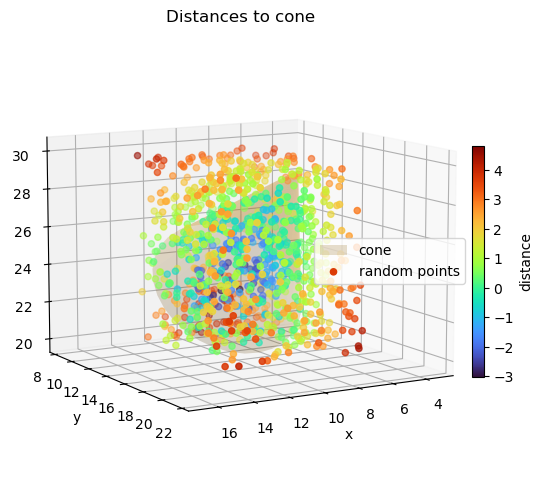

In [93]:
# Generate random points and compute their distance to the cone
random_points = np.random.uniform(
    points_cone.min(axis=0), points_cone.max(axis=0), (1000, 3)
)
dists_cone = dist_to_cone(random_points, *cone_parameters)

# Plot the distances
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot_trisurf(cone_vertices[:, 0], cone_vertices[:, 1], cone_vertices[:, 2], 
                triangles=cone_faces, color="orange", alpha=0.2, label="cone")
p = ax.scatter(random_points[:, 0], random_points[:, 1], random_points[:, 2],
          c=dists_cone, cmap="turbo", label="random points")
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.legend(loc="right")
ax.view_init(10, 60)
cbar = fig.colorbar(p, shrink=0.5, pad=0)
cbar.set_label("distance")
ax.axis("equal")
ax.set_title("Distances to cone")
plt.show()


### Least squares cone

Unlike planes and spheres, cones do not admit a simple closed-form least-squares solution. The approach presented here is inspired by \cite{eberly1999least}.

Starting from the Cartesian equation of the cone:

\begin{equation*}
    x^{2} + y^{2} = z^{2}\tan^{2}\alpha
\end{equation*}

it can be rewritten as:

\begin{equation*}
    x^{2} + y^{2} + z^{2} - z^{2}(1 + \tan^{2}\alpha) = 0
\end{equation*}

Expressing the points in a reference frame whose axis is aligned with the cone direction $n$ leads to the implicit function:

\begin{equation*}
    f(c, n, \alpha) = ||p - c||^{2} - (1 + \tan^{2}\alpha) [n \cdot (p - c)]^{2}
\end{equation*}

The associated least-squares problem is:

\begin{equation*}
    E(c, n, \alpha) = \sum_{i=0}^{N-1} f_{i} (c, n, \alpha)^{2}
\end{equation*}

The unknowns are the cone apex $c$, axis direction $n$, and half-angle $\alpha$.

These parameters can be estimated using a nonlinear least-squares optimizer such as Levenberg-Marquardt. In practice, the `least_squares` function from `scipy.optimize` makes this straightforward: only the distance function and an initial parameter estimate need to be provided.

The implementation below follows this approach. The cone axis is represented using spherical coordinates, reducing the number of optimized parameters from three to two. The point cloud is also centered on its centroid before optimization to improve numerical stability. The Levenberg-Marquardt algorithm (`method="lm"`) is used because it is efficient for small nonlinear least-squares problems. Since it does not support parameter bounds, non-physical parameter values may occasionally be produced and require post-processing.

In [94]:
def fit_cone(points, apex_guess, normal_guess, half_angle_guess):
    """Least squares cone."""

    # Center the pointcloud
    centroid = points.mean(axis=0)
    centered_points = points - centroid
    # Initial parameter estimate
    initial_parameters = np.empty(6)
    initial_parameters[:3] = apex_guess - centroid # points are already centered
    initial_parameters[3:5] = cartesian_to_spherical(normal_guess)
    initial_parameters[5] = half_angle_guess
    # Optimal cone parameters
    result = least_squares(
        lambda x : cone_residuals(x, centered_points),
        initial_parameters,
        method="lm", # Levenberg-Marquardt method
    )
    # Recover parameters
    parameters = result.x
    apex = parameters[:3] + centroid
    normal = spherical_to_cartesian(parameters[3:5])
    half_angle = parameters[-1]
    length = -np.min((points - apex) @ normal)
    
    return (apex, normal, half_angle, length), result.cost


def cone_residuals(parameters, points):
    """Function which computes the vector of residuals."""

    # Recover parameters
    apex = parameters[:3]
    normal = spherical_to_cartesian(parameters[3:5])
    half_angle = parameters[-1]
    # Squared distances to apex
    squared_distance = np.sum((points - apex)**2, axis=1)
    # Projection on axis
    proj_axis = (points - apex) @ normal

    return squared_distance - (1 + np.tan(half_angle)**2) * proj_axis**2



The quality of the initial guesses has a strong influence on convergence and the ability of the optimizer to avoid local minima.

A simple, application-independent approach consists in running the optimization from multiple starting points and keeping the solution with the lowest residual.

Alternatively, geometric information can be exploited. For example, *Principal Component Analysis* (PCA) may be used to estimate the cone axis. For sufficiently elongated cones, the first principal component often provides a good approximation of the axis direction. The apex can then be approximated from the extremal points along this axis, while the half-angle can be estimated from the relationship between the radial distance to the axis and the distance to the apex.

In [95]:
def cone_initial_guess(points):
    """PCA-based cone initialization."""

    # PCA
    centroid = points.mean(axis=0)
    centered_points = points - centroid
    cov = centered_points.T @ centered_points
    _, eigenvectors = np.linalg.eigh(cov)
    # Largest variance direction
    normal_guess = eigenvectors[:, -1]
    # Apex candidate
    projections = centered_points @ normal_guess
    apex_guess = points[np.argmax(projections)]
    # Ensure the axis points from base to apex
    projections = (points - apex_guess) @ normal_guess
    if projections.mean() > 0:
        normal_guess *= -1
        projections *= -1
    # Estimate half-angle
    radial_distances = np.linalg.norm(
        np.cross(normal_guess, points - apex_guess),
        axis=1,
    )
    mask = projections < -1e-6
    tangents = radial_distances[mask] / (-projections[mask])
    half_angle_guess = np.arctan(np.median(tangents))

    return apex_guess, normal_guess, half_angle_guess

best-fit cone apex is: [10. 20. 30.]
best-fit cone normal is: [0.    0.707 0.707]
best-fit cone half-angle is: 0.3926990816987241
best-fit cone length is: 9.969394874582537
residual is: 9.857360126920467e-26


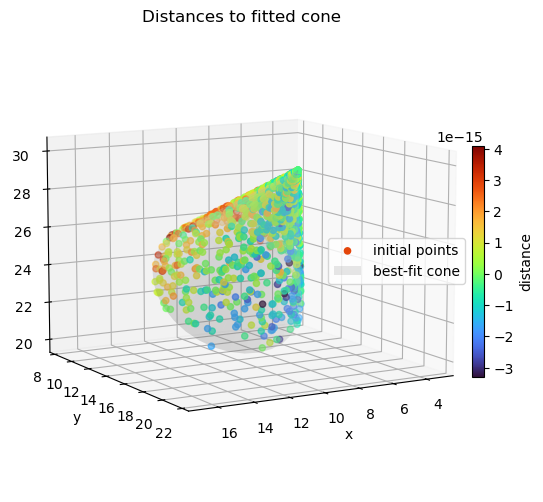

In [96]:
# Initial parameter estimation with PCA
initial_parameters_cone = cone_initial_guess(points_cone)
# Fit cone
cone_fit, cone_residual = fit_cone(points_cone, *initial_parameters_cone)
# Display estimated parameters
with np.printoptions(precision=3, suppress=True):
    for name, val in zip(
            ["apex", "normal", "half-angle", "length"],
            cone_fit
        ):
            print(f"best-fit cone {name} is: {val}")
    print(f"residual is: {cone_residual}")

# Generate mesh for visualization
cone_fit_vertices, cone_fit_faces = generate_cone_mesh(*cone_fit)
# Show distance to best-fit
dists_cone_fit = dist_to_cone(points_cone, *cone_fit)

# Plot the fitted cone and distances
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
p = ax.scatter(points_cone[:, 0], points_cone[:, 1], points_cone[:, 2],
          c=dists_cone_fit, cmap="turbo", label="initial points")
ax.plot_trisurf(cone_fit_vertices[:, 0], cone_fit_vertices[:, 1],
                cone_fit_vertices[:, 2], triangles=cone_fit_faces, 
                color="white", alpha=0.2, label="best-fit cone")
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.legend(loc="right")
ax.view_init(10, 60)
cbar = fig.colorbar(p, shrink=0.5, pad=0)
cbar.set_label("distance")
ax.axis("equal")
ax.set_title("Distances to fitted cone")
plt.show()


## Torus

### Torus parameters

A torus aligned with the $z$-axis can be represented by:

\begin{equation*}
    (\sqrt{(x - c_x)^2 + (y - c_y)^2} - R)^2 + (z - c_z)^2 = r^2
\end{equation*}

A torus of arbitrary orientation is considered here. It is defined by its center $c$, axis direction $n$, major radius $R$, and minor radius $r$. The major radius $R$ is the distance between the torus center and the center of its tube, while the minor radius $r$ is the radius of the tube itself.

| Parameter | Description |
|:----------|:------------|
| $c$       | center      |
| $n$       | unit vector defining the axis direction |
| $R$       | major radius |
| $r$       | minor radius |


In [97]:
def generate_torus_points(center, normal, major_radius, minor_radius, n=1000):
    """Generate random points on a torus."""

    # Generate points on a torus aligned with the z-axis
    theta = np.random.uniform(0., 2*np.pi, (n, 1)) 
    phi = np.random.uniform(0., 2*np.pi, (n, 1))
    x = (major_radius+ minor_radius * np.cos(theta)) * np.cos(phi)
    y = (major_radius + minor_radius * np.cos(theta)) * np.sin(phi)
    z = minor_radius * np.sin(theta)
    points = np.hstack((x, y, z))
    # Rotate to the desired orientation
    R = rotation_f_to_t(np.array([0., 0., 1.]), normal)
    points = (R @ points.T).T
    # Translate to the desired position
    return points + center


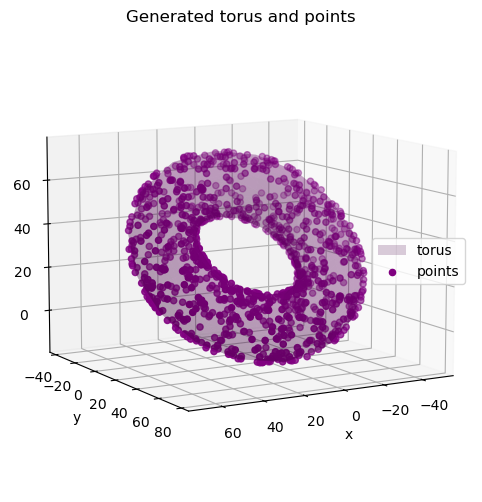

In [98]:
# Define torus parameters
torus_parameters = (
    np.array([10., 20., 30.]), # center
    np.array([0., np.sqrt(2)/2., np.sqrt(2)/2.]), # axis direction
    40., # major radius
    15. # minor radius
)
# Generate points
points_torus = generate_torus_points(*torus_parameters)
# Generate a mesh for visualization 
torus_vertices, torus_faces = generate_torus_mesh(*torus_parameters)

# Plot the torus and points
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot_trisurf(torus_vertices[:, 0], torus_vertices[:,1], torus_vertices[:,2], 
                triangles=torus_faces, color="purple", alpha=0.2,label="torus")
ax.scatter(points_torus[:, 0], points_torus[:, 1], points_torus[:, 2],
           c="purple", label="points")
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.legend(loc="right")
ax.view_init(10, 60)
ax.axis("equal")
ax.set_title("Generated torus and points")
plt.show()


### Point-to-torus distance

The signed distance between a point $p$ and a torus $T$ is:

\begin{equation*}
    d(p, T) = \sqrt{[n \cdot (p - c)]^2 + (|| n \times (p - c) || - R)^2} - r
\end{equation*}

The first term is the distance between the point and the circle of center $c$, radius $R$, and axis direction $n$.

Positive distances correspond to points outside the torus, while negative distances correspond to points inside it.


In [99]:
def dist_to_torus(points, center, normal, major_radius, minor_radius):
    """Signed distance to the torus."""

    vec_to_center = points - center
    d_a = vec_to_center @ normal # axial distance
    d_r = np.linalg.norm(np.cross(normal, vec_to_center), axis=1) # radial

    return np.sqrt(d_a**2 + (d_r - major_radius)**2) - minor_radius


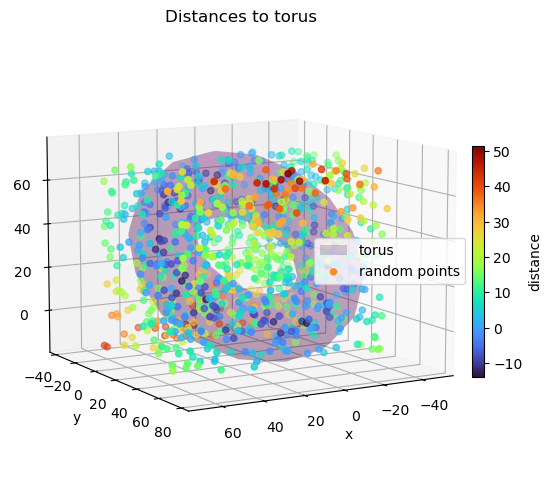

In [100]:
# Generate random points and compute their distance to the torus
random_points = np.random.uniform(
    points_torus.min(axis=0), points_torus.max(axis=0), (1000, 3)
)
dists_torus = dist_to_torus(random_points, *torus_parameters)

# Plot the distances
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot_trisurf(torus_vertices[:, 0], torus_vertices[:,1], torus_vertices[:,2], 
                triangles=torus_faces, color="purple", alpha=0.2, label="torus")
p = ax.scatter(random_points[:, 0], random_points[:, 1], random_points[:, 2],
          c=dists_torus, cmap="turbo", label="random points")
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.legend(loc="right")
ax.view_init(10, 60)
cbar = fig.colorbar(p, shrink=0.5, pad=0)
cbar.set_label("distance")
ax.axis("equal")
ax.set_title("Distances to torus")
plt.show()


### Least squares torus

Unlike planes and spheres, tori do not admit a simple closed-form least-squares solution. The approach presented here follows \cite{eberly2018fitting}.

Starting from the Cartesian equation of the torus:

\begin{equation*}
    (\sqrt{x^2 + y^2} - R)^2 + z^2 = r^{2}
\end{equation*}

it can be rewritten as:

\begin{equation*}
    (x^2 + y^2 + z^2 + R^2 - r^2)^2 - 4R^{2}(x^2 + y^2) = 0
\end{equation*}

Expressing the points in a reference frame whose axis is aligned with the torus direction $n$ leads to the following squared form of the implicit equation:

\begin{equation*}
f(c, n, R^2, r^2) = (||p - c||^2 + R^2 - r^2)^2 - 4R^2(||p - c||^2 - [n \cdot (p - c)]^2)
\end{equation*}

The associated least-squares problem is:

\begin{equation*}
E(c, n, R^2, r^2) = \sum_{i=0}^{N-1} f_{i} (c, n, R^2, r^2)^2
\end{equation*}

The unknowns are the torus center $c$, axis direction $n$, squared major radius $R^2$, and squared minor radius $r^2$.

These parameters can be estimated using a nonlinear least-squares optimizer such as Levenberg-Marquardt. In practice, the `least_squares` function from `scipy.optimize` only requires the residual function and an initial parameter estimate.

However, instead of minimizing the squared implicit equation, one may directly minimize the unsquared implicit equation:

\begin{equation*}
    f'(c, n, R, r) = || p - c ||^2 + R^2 - r^2 - 2R \sqrt{|| p-c ||^2 - [n \cdot (p - c)]^{2}}
\end{equation*}

The implementation below follows this approach. The torus axis is represented using spherical coordinates, reducing the number of optimized parameters from three to two. The pointcloud is also centered on its centroid before optimization to improve numerical stability. The Levenberg-Marquardt algorithm (`method="lm"`) is used because it is efficient for small nonlinear least-squares problems. Since it does not support parameter bounds, the fitted radii may occasionally take non-physical values and are therefore post-processed after optimization.

In [101]:
def fit_torus(points, center_guess, normal_guess, major_radius_guess,
              minor_radius_guess):
    """Least squares torus."""

    # Center the pointcloud
    centroid = points.mean(axis=0)
    centered_points = points - centroid
    # Initial parameter estimate
    initial_parameters = np.empty(7)
    initial_parameters[:3] = center_guess - centroid
    initial_parameters[3:5] = cartesian_to_spherical(normal_guess)
    initial_parameters[5] = major_radius_guess
    initial_parameters[6] = minor_radius_guess
    # Optimal parameters
    result = least_squares(
        lambda x : torus_residuals(x, centered_points),
        initial_parameters,
        method="lm", # Levenberg-Marquardt method
    )
    # Retrieve parameters
    parameters = result.x
    center = parameters[:3] + centroid
    normal = spherical_to_cartesian(parameters[3:5])
    major_radius = np.abs(parameters[5])
    minor_radius = np.abs(parameters[6])
    
    return (center, normal, major_radius, minor_radius), result.cost


def torus_residuals(parameters, points):
    """Function which computes the vector of residuals."""

    center = parameters[:3]
    normal = spherical_to_cartesian(parameters[3:5])
    major_radius = parameters[-2]
    minor_radius = parameters[-1]
    # squared distances to center
    squared_distance = np.sum((points - center)**2, axis=1)
    # projection on axis
    proj_axis = (points - center) @ normal

    return (squared_distance + major_radius**2 - minor_radius**2 
            - 2 * major_radius * np.sqrt(squared_distance - proj_axis**2))
 

The quality of the initial guesses has a strong influence on convergence and robustness.

A generic strategy consists in testing multiple starting points and selecting the solution with the lowest residual.

Alternatively, geometric information can be exploited. For example, *Principal Component Analysis* (PCA) may be used to estimate the torus axis from the direction of smallest variance (under the hypothesis that the torus is relatively thin along its normal direction). The torus center can then be approximated by the centroid, while the major and minor radii may be estimated from the distribution of distances between the points and the estimated axis.

In [102]:
def torus_initial_guess(points):
    """PCA-based torus initialization."""

    # Center estimate
    center = points.mean(axis=0)
    # Axis estimate
    centered_points = points - center
    cov = centered_points.T @ centered_points
    _, eigenvectors = np.linalg.eigh(cov)
    # Smallest variance direction
    normal = eigenvectors[:, 0]
    # Distance to the estimated axis
    d_r = np.linalg.norm(
        np.cross(normal, centered_points),
        axis=1
    )
    # Radii estimates
    major_radius = d_r.mean()
    minor_radius = np.sqrt(np.mean((d_r - major_radius) ** 2))

    return center, normal, major_radius, minor_radius

best-fit torus center is: [10. 20. 30.]
best-fit torus normal is: [0.    0.707 0.707]
best-fit torus major_radius is: 39.99999999999999
best-fit torus minor_radius is: 15.0
residual is: 8.297655519672559e-23


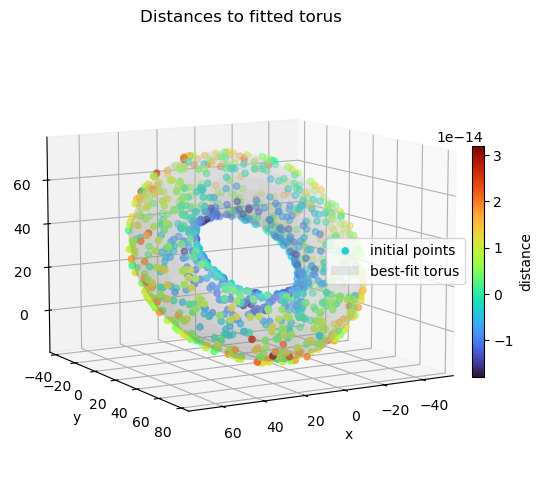

In [103]:
# Initial parameter estimate
initial_parameters_torus = torus_initial_guess(points_torus)
# Fit the torus
torus_fit, torus_residual = fit_torus(points_torus, *initial_parameters_torus)
# Display estimated parameters
with np.printoptions(precision=3, suppress=True):
    for name, val in zip(
            ["center", "normal", "major_radius", "minor_radius"],
            torus_fit
        ):
            print(f"best-fit torus {name} is: {val}")
    print(f"residual is: {torus_residual}")

# Generate a mesh for visualization 
torus_fit_vertices, torus_fit_faces = generate_torus_mesh(*torus_fit)
# Compute distances to the fitted torus
dists_torus_fit = dist_to_torus(points_torus, *torus_fit)

# Plot the fitted torus and distances
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
p = ax.scatter(points_torus[:, 0], points_torus[:, 1], points_torus[:, 2],
               c=dists_torus_fit, cmap="turbo", label="initial points")
ax.plot_trisurf(torus_fit_vertices[:, 0], torus_fit_vertices[:, 1],
                torus_fit_vertices[:,2], triangles=torus_fit_faces,
                color="white", alpha=0.2, label="best-fit torus")
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.legend(loc="right")
ax.view_init(10, 60)
cbar = fig.colorbar(p, shrink=0.5, pad=0)
cbar.set_label("distance")
ax.axis("equal")
ax.set_title("Distances to fitted torus")
plt.show()


## Validity of fitted primitives

Least-squares fitting always produces a solution, even when the chosen primitive is not a good representation of the points. It is therefore important to assess the validity of the fitted primitive.

A common approach consists in analyzing the **distribution of residuals**, which quantify the deviation between the points and the fitted primitive. Under the assumption that the points are independently affected by zero-mean Gaussian noise with standard deviation $\sigma$, the residual follows a $\chi^2$ distribution with $k$ degrees of freedom, where $k$ is approximately equal to the number of points $n$ for large pointclouds.

Based on this observation, a simple residual-based validity test \cite{goulette1997automatic} considers that a point is compatible with the fitted primitive if its squared residual satisfies:

\begin{equation*}
    d(p_i, S(\theta))^2 < 3\sigma^2
\end{equation*}

Assuming that a large majority of points should satisfy this criterion, it may be extended to a primitive-level test by considering the total residual. A fitted primitive can then be regarded as valid if:

\begin{equation*}
    res(\theta) < 3n\sigma^2
\end{equation*}

This provides a simple way to reject primitives whose residuals are inconsistent with the expected measurement noise.

Other validation strategies exist. When the Gaussian-noise assumption is questionable, residuals may be compared against a theoretical or empirical distribution using goodness-of-fit tests such as the Kolmogorov-Smirnov test. Another option is cross-validation, in which part of the points is withheld during fitting and later used for evaluation. Such methods can provide a more robust assessment of model quality and parameter stability, but generally require additional assumptions or incur a higher computational cost.

Total residual is 9.8 and validity threshold is 30.0


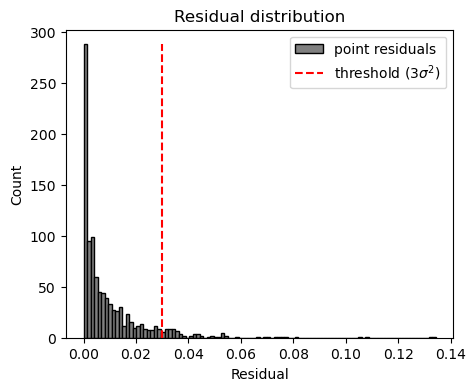

In [104]:
# Generate points on a plane
points_plane_noise = generate_plane_points(
    [0., 0., 0.], [0., 0., 1.], [0., 1., 0.], 50, 80, n=1000
)
# Add some Gaussian noise
sigma = 0.1
points_plane_noise += np.random.normal(0., sigma, points_plane_noise.shape)
# Fit plane to noisy pointcloud
plane_fit, plane_residual = fit_plane(points_plane_noise)
# Compute residual for each point
dists_best_fit_plane = dist_to_plane(points_plane_noise, *plane_fit)
residuals = dists_best_fit_plane**2
# Test that residuals are compatible with the noise level
threshold = 3 * len(points_plane_noise) * sigma**2
print(f"Total residual is {plane_residual:.1f} and validity threshold is {
    threshold:.1f}")

# Plot residuals distribution
fig, ax = plt.subplots(figsize=(5, 4))
n, *_ = ax.hist(residuals, bins=100, color="gray", edgecolor="black",
                label="point residuals")
ax.vlines(3*(sigma**2), 0, np.max(n), colors="red", linestyles="dashed",
          label="threshold ($3\\sigma^2$)")
ax.legend()
ax.set_xlabel("Residual")
ax.set_ylabel("Count")
ax.set_title("Residual distribution")
plt.show()


## Wrapping up

This notebook introduced some of the most common geometric primitives used in 3D processing, namely planes, spheres, cylinders, cones, and tori. For each primitive, the associated parameters, distance function, and fitting algorithms were presented.

The least-squares approach was used throughout the notebook because of its simplicity and the availability of efficient numerical solvers. However, its performance depends on the quality of the data and may be affected by noise, outliers, or poor initialization.

Primitive fitting is a common way to simplify and organize pointclouds. By replacing many points with a small number of parametric surfaces, it produces a representation that is easier to store, analyze, and manipulate. In practice, primitive fitting is often only one step of a larger workflow, where the fitted primitives are used for tasks such as object modeling, reverse engineering, or scene understanding.
